Max Starting Mach: 2.4771

NASA Limits:
  Minimum Lower Surface Mach: 0.9264
  Maximum Upper Surface Mach: 1.6248


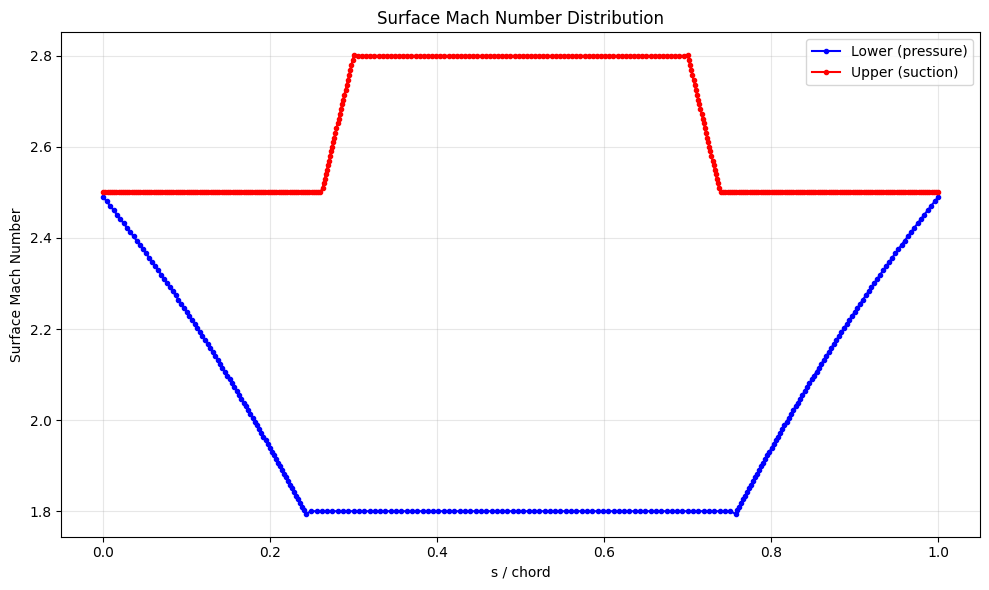


--- Separation Risk Analysis ---
Lower Surface:
  Max H_i: 2.200 at s/c = 0.243 -> AT RISK (Transitioning/Separating)
Upper Surface:
  Max H_i: 2.246 at s/c = 0.740 -> AT RISK (Transitioning/Separating)


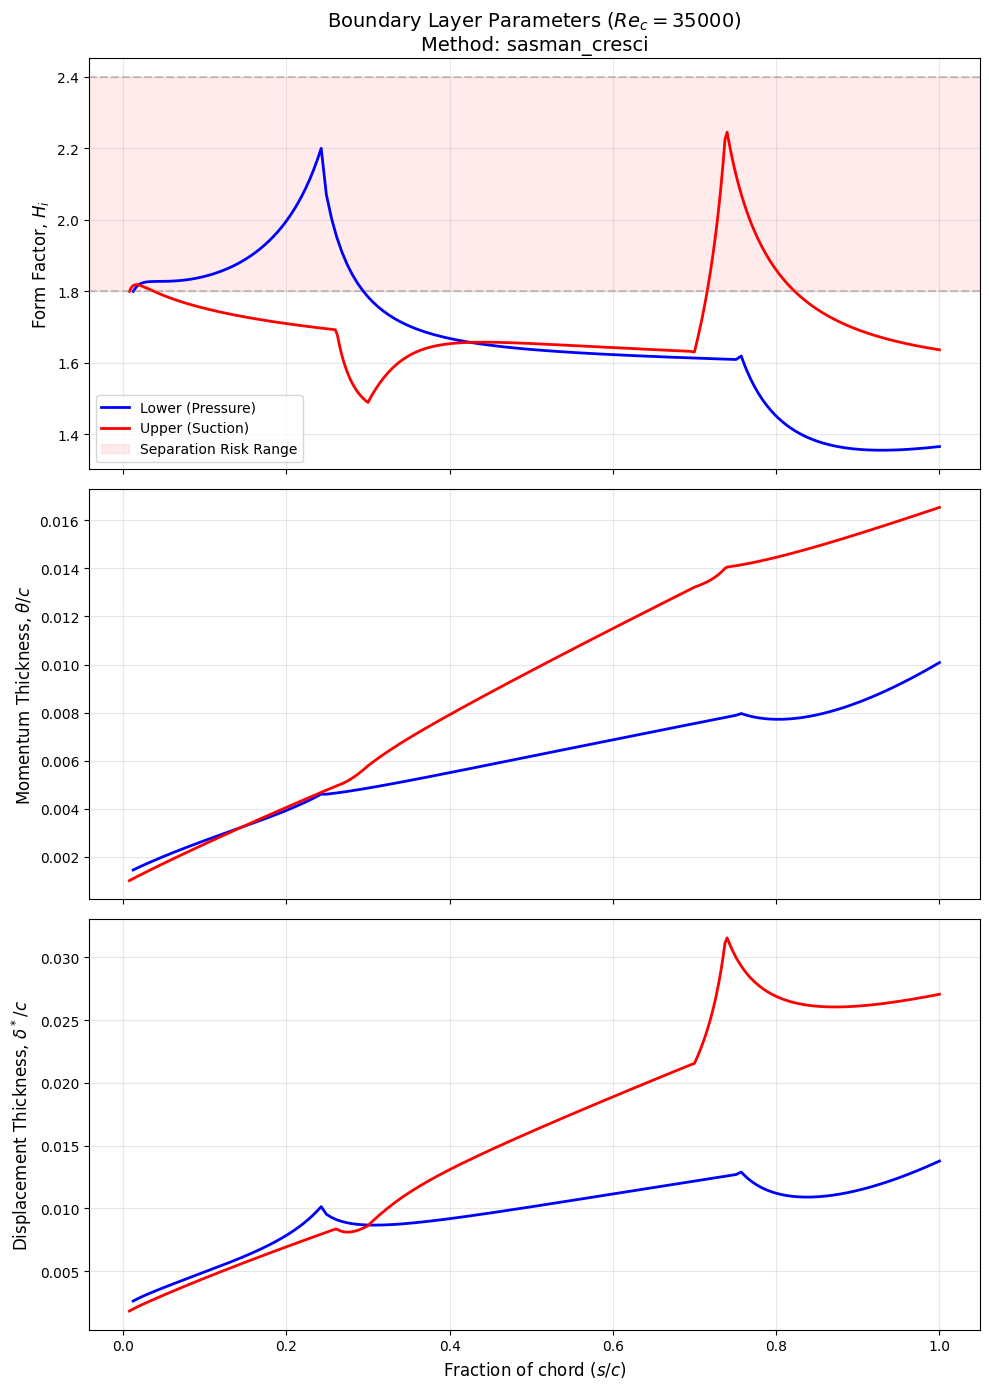

In [12]:
import importlib
import prop_components.turbinemoc
from prop_components.turbine import Turbine
from prop_components.turbinemoc import SupersonicTurbineMOC
from prop_components.blade_profiler import DisplacedBladeProfiler

importlib.reload(prop_components.turbinemoc) 


# moc = SupersonicTurbineMOC(
#     gamma=1.4, 
#     mach_inlet=1.7, 
#     mach_lower=1.1, 
#     mach_upper=2, 
#     beta_inlet_deg=75.0, 
#     dv=0.004
# )
moc = SupersonicTurbineMOC(
    gamma=1.4, 
    mach_inlet=2.5, 
    mach_lower=1.8, 
    mach_upper=2.8, 
    beta_inlet_deg=70.0, 
    dv=0.004
)
# moc = SupersonicTurbineMOC(
#     gamma=1.4, 
#     mach_inlet=1.7, 
#     mach_lower=1.1, 
#     mach_upper=2, 
#     beta_inlet_deg=75.0, 
#     dv=0.004
# )


# moc = SupersonicTurbineMOC(
#     gamma=1.4, 
#     mach_inlet=1.3, 
#     mach_lower=1.05, 
#     mach_upper=1.5, 
#     beta_inlet_deg=75.0, 
#     dv=0.004
# )

# 1. Generate Coordinates
coords = moc.generate()

# 2. Print Summary
# moc.print_summary()

from prop_components.turbine import SupersonicStartingGoldman
starting_checker = SupersonicStartingGoldman(1.4)
start_results = starting_checker.check_starting(M_inlet=moc.mach_inlet, Msl=starting_checker.mstar_from_mach(moc.mach_lower, 1.4), Msu=starting_checker.mstar_from_mach(moc.mach_upper, 1.4))
print(f"Max Starting Mach: {start_results['M_inlet_max']:.4f}")

# 3. Use NASA limit checker
Ml_min, Mu_max = SupersonicTurbineMOC.get_nasa_limits(mach_inlet=1.3, gamma=1.4)
print(f"\nNASA Limits:")
print(f"  Minimum Lower Surface Mach: {Ml_min:.4f}")
print(f"  Maximum Upper Surface Mach: {Mu_max:.4f}")

# 4. Plot (unrotated frame by default, pass unrotated=False for rotated)
# moc.plot_blade(unrotated=False, full_passage=True, plot_characteristics=False)
moc.surface_mach_distribution(plot=True)

turbine = Turbine(
    P=2600,          
    RPM=20000,       
    d_mean_mm=95,   
    mdot=0.0428,     
    beta_deg=15.0,   
    doa=0.15,         
    p_e=1.1e5        
)
turbine.from_inert_gas_real(R=287, gam=1.4, T01=300, nozzles=3)
profiler = DisplacedBladeProfiler(turbine, moc, bl_method='sasman_cresci')

# Evaluate boundary layers and run displacement
profiler.evaluate_boundary_layers(re_chord=35000, Hi_0=1.8, theta_0_test=10)
# profiler.displace_contour()

# Separation Risk
profiler.analyze_separation_risk()
# profiler.plot_displaced_contour()
profiler.plot_boundary_layer_parameters()